# Assignment: Exploratory Data Analysis

**Q1.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `./data/ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
6. Which giftors provide the most money, in total?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Christopher Currie

**Date:** 09/07/26

count    2.822100e+04
mean     5.882327e+05
std      3.222011e+06
min     -5.377700e+05
25%      5.700000e+03
50%      9.461500e+04
75%      3.761420e+05
max      1.000000e+08
Name: Foreign Gift Amount, dtype: float64


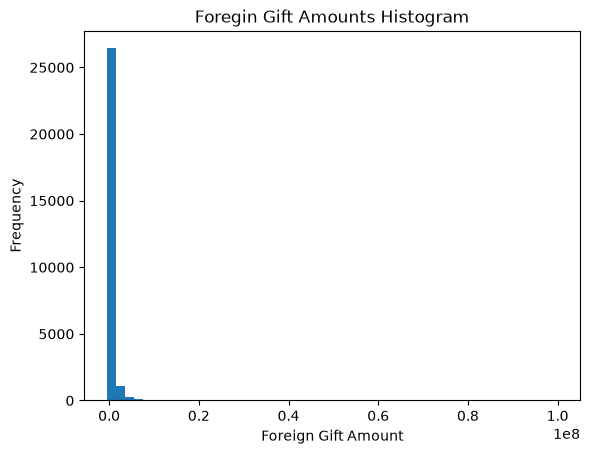

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
#1. Load the `./data/ForeignGifts_edu.csv` dataset.
import pandas as pd
df = pd.read_csv('./data/ForeignGifts_edu.csv')

#2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
plt.hist(df['Foreign Gift Amount'], bins =50)
plt.xlabel('Foreign Gift Amount')
plt.ylabel('Frequency')
plt.title("Foregin Gift Amounts Histogram")

#stats for describing
print(df['Foreign Gift Amount'].describe())

#the amounts are heavily right skwed, the majoiry of the gifts are small but there a few massive figts that push the average to 588233

In [ ]:
# For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?

#Value counts table and proportions for Gift Type
counts = df['Gift Type'].value_counts()
proportions = df['Gift Type'].value_counts(normalize=True)


print (counts)
print (proportions)
#summary for proportions
summary = pd.DataFrame({
    'Count': counts,
    'Proportion': proportions,
    'Percentage': (proportions * 100).map('{:.2f}%'.format)
})

print(summary)

Gift Type
Contract         17274
Monetary Gift    10936
Real Estate         11
Name: count, dtype: int64
Gift Type
Contract         0.612097
Monetary Gift    0.387513
Real Estate      0.000390
Name: proportion, dtype: float64
               Count  Proportion Percentage
Gift Type                                  
Contract       17274    0.612097     61.21%
Monetary Gift  10936    0.387513     38.75%
Real Estate       11    0.000390      0.04%


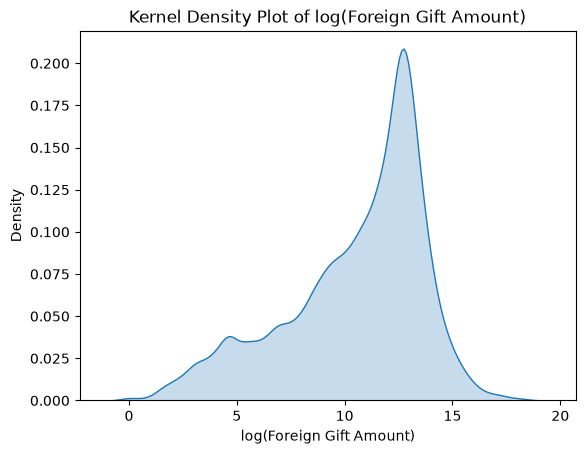

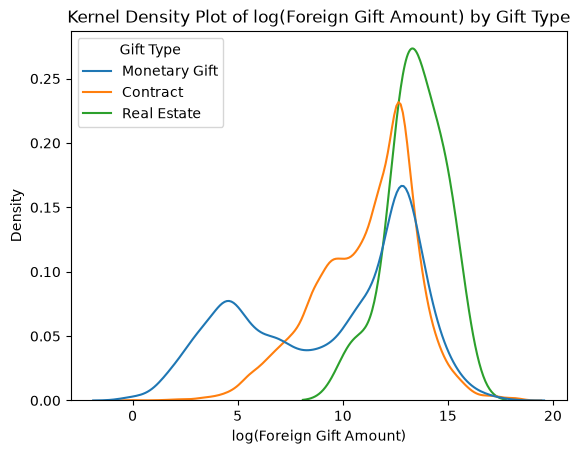

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
#Create a kernel density plot of the log of `Foreign Gift Amount`, 
# and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. 
# Do you notice any patterns?


# Filter positive amounts to take the log
df_pos = df[df['Foreign Gift Amount'] > 0].copy()
df_pos['log_amount'] = np.log(df_pos['Foreign Gift Amount'])

# log of 'Foreign Gift Amount'
sns.kdeplot(df_pos['log_amount'], fill=True)
plt.title('Kernel Density Plot of log(Foreign Gift Amount)')
plt.xlabel('log(Foreign Gift Amount)')
plt.show()

# conditional on Gift Type
sns.kdeplot(data=df_pos, x='log_amount', hue='Gift Type', common_norm=False)
plt.title('Kernel Density Plot of log(Foreign Gift Amount) by Gift Type')
plt.xlabel('log(Foreign Gift Amount)')
plt.show()


#patterns I notice: the log helpes fix the skewing issue and there is much better bell shaped curve 
# and real esate gifts are shifted farthers right which means they have the highest dollar amounts overall.
# Montery gits include more low value gifts compared to there counterparts.


In [19]:
#5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?

#top 15 by number of gifts
t15G = df['Country of Giftor'].value_counts().head(15)
print("Top 15 by number of gifts:") #shown in output 
print(t15G) #prints top 15 countries in mumber of gifts

#top 15 by amount given
t15A = df.groupby('Country of Giftor')['Foreign Gift Amount'].sum().sort_values(ascending=False).head(15)
print("\n Top 15 by amount given:") # shown in output
print(t15A)

Top 15 by number of gifts:
Country of Giftor
ENGLAND            3655
CHINA              2461
CANADA             2344
JAPAN              1896
SWITZERLAND        1676
SAUDI ARABIA       1610
FRANCE             1437
GERMANY            1394
HONG KONG          1080
SOUTH KOREA         811
QATAR               693
THE NETHERLANDS     512
KOREA               452
INDIA               434
TAIWAN              381
Name: count, dtype: int64

 Top 15 by amount given:
Country of Giftor
QATAR                   2706240869
ENGLAND                 1464906771
CHINA                   1237952112
SAUDI ARABIA            1065205930
BERMUDA                  899593972
CANADA                   898160656
HONG KONG                887402529
JAPAN                    655954776
SWITZERLAND              619899445
INDIA                    539556490
GERMANY                  442475605
UNITED ARAB EMIRATES     431396357
FRANCE                   405839396
SINGAPORE                401157692
AUSTRALIA                248409202


In [24]:
#6. Which giftors provide the most money, in total?
 #Qatar Foundation: ~$1.17 Billion ($1,166,503,744)
# Qatar Foundation/Qatar National Res: ~$796.20 Million ($796,197,000)
# Qatar Foundation for Education: ~$373.95 Million ($373,945,215)

#above are the top 3 from the code below, more can be seen by running the code and changing the '10' at the end

# Top giftors by total amount given
top = df.groupby('Giftor Name')['Foreign Gift Amount'].sum().sort_values(ascending=False).head(15)
print(top) #

Giftor Name
Qatar Foundation                       1166503744
Qatar Foundation/Qatar National Res     796197000
Qatar Foundation for Education          373945215
Anonymous                               338793629
Saudi Arabian Cultural Mission          275221475
HCL                                     190000000
Church of Jesus Christ of LDS           185203715
Emirates Institute for Advanced Sc      170641244
QIC                                     148355497
Anonymous #9                             96334996
Qatar National Research Fund             79021705
Government of Saudi Arabia               75192434
Contracting Party                        69996984
CMKL University                          67700000
Royal Embassy of Saudi Arabia            67062486
Name: Foreign Gift Amount, dtype: int64


## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** c1f991e399f9fa919ccbf2cbb3f760aa9e8a9852
- **AI tool and model used:** Gemini (Flash 3.6)

### *Prompts used

1. Ive attached teh images of my work for the following questions: * copied and pasted Q1 * Please return me these images with marked up notes on where I could imporvoe these answers. 
2. I am going to give you a snpitt of my code and the quesiton that code was attmepting to answer please provide me with changes to make it better. *provides quesiton and code* *snippit is the entirety of q2

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. For Q1 I attached two files for the ai suggestions beucase I had it mark up my oringal work, please see those files.
2. see comments on ai markup for quedstino 1
3. see comments on ai markup for quedstino 2
4. Logirthmic scaling for the histogram
5. Data cleaning and currency formatting
6. Handling missing catergoy's and explicitly matching to catergoires
7. Change it to a bar chart
8. Log base 10 scaling
9. Category filtering
10. side by side comparison
11. standizing countries names
12. normalzie giftor names
13. filter out blank entires

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept  | Accepted advice to state what m(x) is equal to at the start becuase it clarfies a truth for the rest of the problem |
| 2 |  reject | Other comments on questions 1-2 for Q1 are very ambigous and hard to read from the AI, I belive it got confused |
| 3 | Accept  | using property m(a+bx) = a +bm(x), made this change becuase it helps with efficiency|
| 4 | Accept  | would solve issue of seeing everything inside one bar|
| 5 | Accept  | Would be smart to handle string symobls such as "$" and ","|
| 6 | Accept  | This would ensure these is no missing catergoies via a typo or mistake and is a good proces to follow|
| 7 | Reject  | The quesiotn I was answering spefically asked for a histogram or value counts table so I do not want to change this|
| 8 | Accept  | this will allow for better interpretablitliy becuase the axis values will be readable in acutl dollar terms|
| 9 | Accept  | Filtering out rare categore helps focus on patterns in the key gifts|
| 10 | Reject  | No need, I did not struggle to compare wtihout this|
| 11 | Accept  | Stadardization always is a good practice in data scinece I have come to learn|
| 12 | Reject  | The ai reccomended this becuase the top 3 giftors all come from a differnt Qatar Foudnation however I belive these should stay seperate as they are beucase to my knolege they are differnt entites despite being part of the Qatar Foudnation|
| 13 | Accept  | Always a good process to filter out blank entries and fix formating|








### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.
# attached updates for question 1 uploaded as files, 
# only image of changes are made, rest remains the same.

Summary Statistics for Foreign Gift Amount:
count       $28,221.00
mean       $588,232.72
std      $3,222,011.43
min       $-537,770.00
25%          $5,700.00
50%         $94,615.00
75%        $376,142.00
max     $99,999,999.00
Name: Foreign Gift Amount, dtype: float64


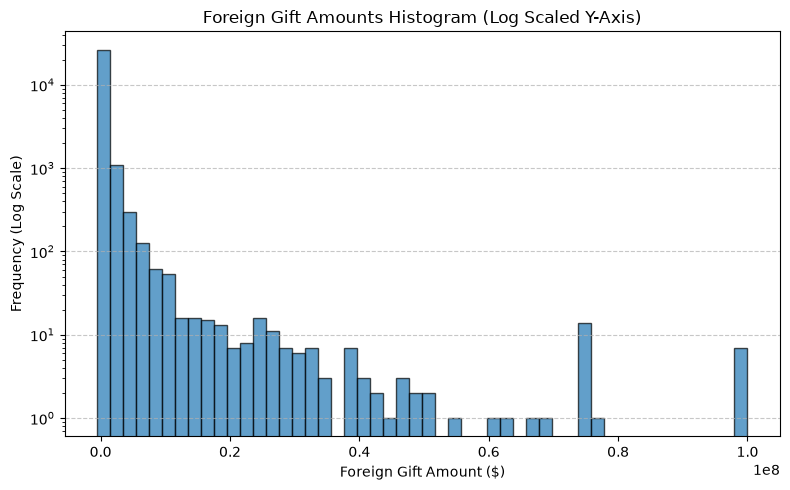

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Load the dataset
df = pd.read_csv("./data/ForeignGifts_edu.csv")

# 2. Clean 'Foreign Gift Amount' (handles string currency values like '$' or ',')
if df["Foreign Gift Amount"].dtype == "object":
    df["Foreign Gift Amount"] = df["Foreign Gift Amount"].astype(str).str.replace(r"[\$,]", "", regex=True)

df["Foreign Gift Amount"] = pd.to_numeric(df["Foreign Gift Amount"], errors="coerce")

# Print clean summary statistics suppressing scientific notation
pd.set_option("display.float_format", lambda x: f"${x:,.2f}")
print("Summary Statistics for Foreign Gift Amount:")
print(df["Foreign Gift Amount"].describe())

# Create a histogram using a logarithmic scale to handle extreme right skewness
plt.figure(figsize=(8, 5))
plt.hist(df["Foreign Gift Amount"].dropna(), bins=50, log=True, edgecolor="black", alpha=0.7)
plt.xlabel("Foreign Gift Amount ($)")
plt.ylabel("Frequency (Log Scale)")
plt.title("Foreign Gift Amounts Histogram (Log Scaled Y-Axis)")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

In [2]:
import pandas as pd

# Calculate overall counts and proportions
counts = df["Gift Type"].value_counts()
proportions = df["Gift Type"].value_counts(normalize=True)

# Build summary DataFrame
summary = pd.DataFrame(
    {
        "Count": counts,
        "Proportion": proportions,
        "Percentage": (proportions * 100).map("{:.2f}%".format),
    }
)

print("--- Overall Gift Type Summary Table ---")
print(summary)

# Explicit category extraction for requested types: Contract, Real Estate, Monetary
target_types = ["Contract", "Real Estate", "Monetary"]

# Filter for exact/case-insensitive matches on requested categories
target_summary = summary[summary.index.astype(str).str.strip().str.title().isin(target_types)]

print("\n--- Target Gift Types Proportions ---")
print(target_summary)

--- Overall Gift Type Summary Table ---
               Count  Proportion Percentage
Gift Type                                  
Contract       17274       $0.61     61.21%
Monetary Gift  10936       $0.39     38.75%
Real Estate       11       $0.00      0.04%

--- Target Gift Types Proportions ---
             Count  Proportion Percentage
Gift Type                                
Contract     17274       $0.61     61.21%
Real Estate     11       $0.00      0.04%


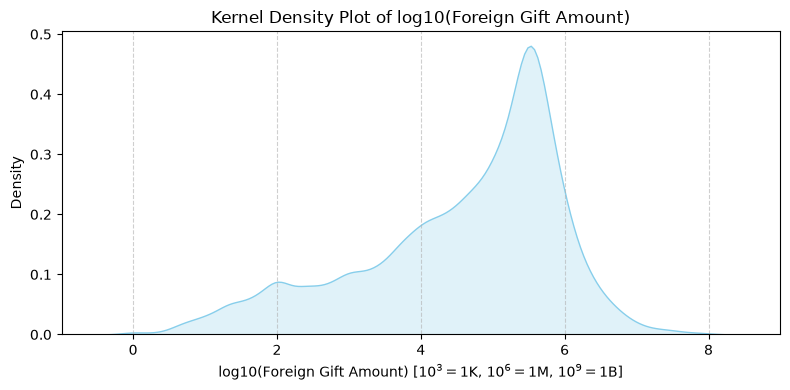

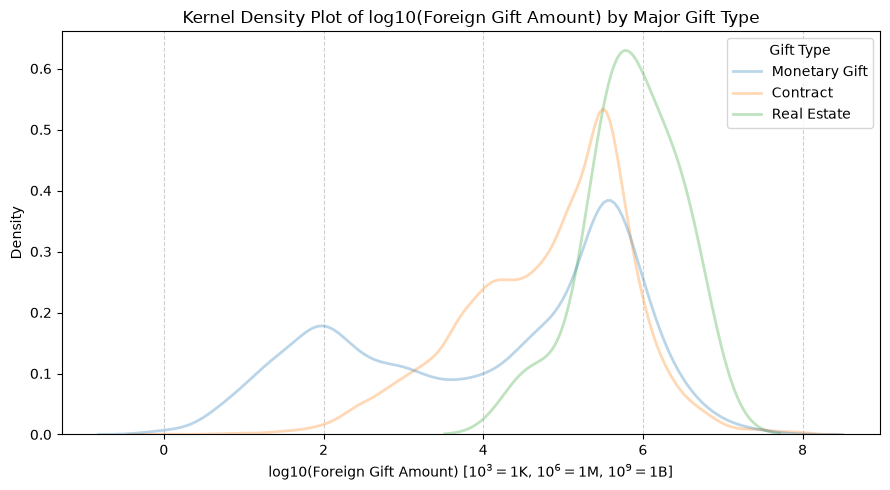

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Filter positive amounts and compute log10 for dollar-scale readability
df_pos = df[df["Foreign Gift Amount"] > 0].copy()
df_pos["log10_amount"] = np.log10(df_pos["Foreign Gift Amount"])

# 1. Overall Kernel Density Plot using Log Base 10
plt.figure(figsize=(8, 4))
sns.kdeplot(df_pos["log10_amount"], fill=True, color="skyblue")
plt.title("Kernel Density Plot of log10(Foreign Gift Amount)")
plt.xlabel("log10(Foreign Gift Amount) [$10^3 = $1K, $10^6 = $1M, $10^9 = $1B]")
plt.ylabel("Density")
plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# 2. Filter for major gift types to reduce visual clutter
top_types = df_pos["Gift Type"].value_counts().nlargest(4).index
df_filtered = df_pos[df_pos["Gift Type"].isin(top_types)]

# Conditional Density Plot by Gift Type
plt.figure(figsize=(9, 5))
sns.kdeplot(
    data=df_filtered,
    x="log10_amount",
    hue="Gift Type",
    common_norm=False,
    linewidth=2,
    alpha=0.3,
)
plt.title("Kernel Density Plot of log10(Foreign Gift Amount) by Major Gift Type")
plt.xlabel("log10(Foreign Gift Amount) [$10^3 = $1K, $10^6 = $1M, $10^9 = $1B]")
plt.ylabel("Density")
plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [5]:
import pandas as pd

# 1. Clean and standardize 'Country of Giftor' (strips whitespace, standardizes case, removes NaNs)
df_clean = df.dropna(subset=["Country of Giftor"]).copy()
df_clean["Country of Giftor"] = df_clean["Country of Giftor"].astype(str).str.strip().str.title()

# Top 15 by number of gifts
t15G = df_clean["Country of Giftor"].value_counts().head(15)
print("Top 15 by number of gifts:")
print(t15G)

# Top 15 by amount given
t15A = (
    df_clean.groupby("Country of Giftor")["Foreign Gift Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)
print("\nTop 15 by amount given:")
print(t15A)

Top 15 by number of gifts:
Country of Giftor
England            3655
China              2461
Canada             2344
Japan              1896
Switzerland        1676
Saudi Arabia       1610
France             1437
Germany            1394
Hong Kong          1080
South Korea         811
Qatar               693
The Netherlands     512
Korea               452
India               434
Taiwan              381
Name: count, dtype: int64

Top 15 by amount given:
Country of Giftor
Qatar                   2706240869
England                 1464906771
China                   1237952112
Saudi Arabia            1065205930
Bermuda                  899593972
Canada                   898160656
Hong Kong                887402529
Japan                    655954776
Switzerland              619899445
India                    539556490
Germany                  442475605
United Arab Emirates     431396357
France                   405839396
Singapore                401157692
Australia                248409202
N

In [6]:
import pandas as pd

# Clean missing or blank giftor names
df_clean = df.dropna(subset=["Giftor Name"]).copy()
df_clean = df_clean[df_clean["Giftor Name"].astype(str).str.strip() != ""]

# Top giftors by total amount given
top = (
    df_clean.groupby("Giftor Name")["Foreign Gift Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

# Format as currency
top_formatted = top.apply(lambda x: f"${x:,.2f}")

print("Top 15 Giftors by Total Amount Given:")
print(top_formatted)

Top 15 Giftors by Total Amount Given:
Giftor Name
Qatar Foundation                       $1,166,503,744.00
Qatar Foundation/Qatar National Res      $796,197,000.00
Qatar Foundation for Education           $373,945,215.00
Anonymous                                $338,793,629.00
Saudi Arabian Cultural Mission           $275,221,475.00
HCL                                      $190,000,000.00
Church of Jesus Christ of LDS            $185,203,715.00
Emirates Institute for Advanced Sc       $170,641,244.00
QIC                                      $148,355,497.00
Anonymous #9                              $96,334,996.00
Qatar National Research Fund              $79,021,705.00
Government of Saudi Arabia                $75,192,434.00
Contracting Party                         $69,996,984.00
CMKL University                           $67,700,000.00
Royal Embassy of Saudi Arabia             $67,062,486.00
Name: Foreign Gift Amount, dtype: str


### *Reflection on AI assistance
In your own words without generative AI.



[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]


The main improvements I made with regard to question two were handling blank/missing data and text standardization. I do not belvie this had to big of effect ont he outcome due to the cleanliness of the data to begin with however the proces the ai recommend was a much safer approach then what I had roingally and I was able to verify the ai recommendations with my phase on esoultions. Logarithmic scaling was another big thing the AI recommended that I will be implementing in the future because it makes the histograms hold so much value and are much easier to interpret in that form. One drawback of the AI is that its advice on question 1 was not that strong. I attempted to have it mark up my writing work, and it did pretty well with this on my first sheet of work but poorly on the second. AI is definitely not as strong as editing pictures, which,h in a way, is what I asked it to do, so I probably could've gotten better information if I had prompted it differently; nevertheless, it was a feature I wanted to try, and if perfected, could be very useful for all sorts of math courses. 
